In [ ]:
import pandas as pd
import numpy as np

def robust_harmonize_clinical_data_gse75010(df_raw):
    """
    Processa e harmoniza de forma robusta os metadados clínicos brutos do dataset GSE75010.
    Esta função foi projetada para lidar com as inconsistências de nomenclatura encontradas
    nos ficheiros SOFT do GEO.

    Args:
        df_raw (pd.DataFrame): DataFrame contendo os metadados brutos, incluindo
                               uma coluna 'gsm_id' e 'characteristics_ch1'.

    Returns:
        pd.DataFrame: Um DataFrame limpo e padronizado com as variáveis clínicas.
    """
    # CORREÇÃO 1: A variável 'harmonized_data' precisa ser inicializada como uma lista vazia.
    harmonized_data = []

    for _, row in df_raw.iterrows():
        sample_id = row['gsm_id']
        characteristics_list = row.get('characteristics_ch1', []) # Usar default como lista vazia

        # 1. Extrai todos os pares chave-valor para um dicionário flexível
        char_dict = {}
        if isinstance(characteristics_list, list):
            for item in characteristics_list:
                parts = str(item).split(':', 1)
                if len(parts) == 2:
                    # CORREÇÃO 2: .strip() e .lower() devem ser aplicados aos elementos da lista ('parts[0]', 'parts[1]'),
                    # e não à lista 'parts' em si.
                    key = parts[0].strip().lower()
                    value = parts[1].strip()
                    char_dict[key] = value

        # 2. Mapeia as chaves encontradas para um esquema padronizado
        sample_data = {'sample_id': sample_id}

        # Status da Pré-eclâmpsia (PE)
        diagnosis = char_dict.get('diagnosis', '').lower()
        sample_data['pe_status'] = 1 if 'pe' in diagnosis else 0

        # Idade Gestacional (combinando semanas e dias)
        try:
            ga_weeks = pd.to_numeric(char_dict.get('ga (week)'), errors='coerce')
            ga_days = pd.to_numeric(char_dict.get('ga (day)'), errors='coerce')
            if pd.notna(ga_weeks):
                # Calcula a idade gestacional total em semanas
                total_ga = ga_weeks + (ga_days / 7 if pd.notna(ga_days) else 0)
                sample_data['gestational_age_weeks'] = total_ga
            else:
                sample_data['gestational_age_weeks'] = np.nan
        except Exception:
            sample_data['gestational_age_weeks'] = np.nan

        # Pressão Arterial
        sample_data['systolic_bp'] = pd.to_numeric(char_dict.get('maximum systolic bp'), errors='coerce')
        sample_data['diastolic_bp'] = pd.to_numeric(char_dict.get('maximum diastolic bp'), errors='coerce')

        # Proteinúria
        sample_data['proteinuria'] = char_dict.get('mode proteinuria')

        # Índice de Pulsatilidade da Artéria Uterina
        sample_data['uterine_artery_pi'] = pd.to_numeric(char_dict.get('mean uterine pi'), errors='coerce')

        # Síndrome HELLP
        hellp = char_dict.get('hellp diagnosis', 'no').lower()
        sample_data['hellp_syndrome'] = 1 if hellp == 'yes' else 0

        # Outras variáveis importantes
        sample_data['maternal_age'] = pd.to_numeric(char_dict.get('maternal age'), errors='coerce')
        sample_data['maternal_bmi'] = pd.to_numeric(char_dict.get('maternal bmi'), errors='coerce')
        sample_data['ethnicity'] = char_dict.get('maternal ethnicity')

        # A publicação original menciona subtipos, mas eles não estão nos metadados do GEO.
        # Seriam derivados da análise de expressão ou obtidos de outra fonte.
        # Adicionamos a coluna para consistência com o plano de pesquisa.
        sample_data['molecular_subtype'] = char_dict.get('molecular subtype') # Provavelmente será NaN

        harmonized_data.append(sample_data)

    return pd.DataFrame(harmonized_data)


In [ ]:
import requests
import os

def download_updated_datasets(output_dir="datasets"):
    """
    Baixa os datasets essenciais para a análise da pré-eclâmpsia, utilizando
    URLs atualizadas e validadas do Broad Institute MSigDB.

    1. Dataset GSE75010 do NCBI GEO (usando GEOparse, como no script original).
    2. Ficheiros de referência Hallmark, KEGG MEDICUS e GO_BP (GMT).
    """
    print("=" * 60)
    print("INICIANDO DOWNLOAD DOS DATASETS COM SCRIPTS ATUALIZADOS")
    print("=" * 60)

    os.makedirs(output_dir, exist_ok=True)
    print(f"Os ficheiros serão salvos em: '{os.path.abspath(output_dir)}'")

    # --- 1. Baixar dados do GEO (mantém-se a abordagem original, que funcionou) ---
    # (O código para baixar o GSE75010 com GEOparse seria inserido aqui)
    print("\n[1/4] Download do GSE75010... (Assumindo já concluído com sucesso)")

    # --- 2. Baixar ficheiros GMT com URLs corrigidas ---
    # URLs validadas para a versão mais recente do MSigDB (ex: 2024.1.Hs)
    # É boa prática verificar a versão mais recente no site do GSEA-MSigDB.
    msigdb_version = "2024.1.Hs"
    base_url = f"https://data.broadinstitute.org/gsea-msigdb/msigdb/release/{msigdb_version}/"

    gmt_files = {
        'Hallmark': f"{base_url}h.all.v{msigdb_version}.symbols.gmt",
        'KEGG_MEDICUS': f"{base_url}c2.cp.kegg_medicus.v{msigdb_version}.symbols.gmt",
        'GO_BP': f"{base_url}c5.go.bp.v{msigdb_version}.symbols.gmt"
    }

    for i, (name, url) in enumerate(gmt_files.items()):
        filename = f"{name.lower()}_gene_sets.gmt"
        filepath = os.path.join(output_dir, filename)

        print(f"\n[{i+2}/4] Baixando ficheiro de referência '{name}' GMT...")
        try:
            response = requests.get(url)
            response.raise_for_status()  # Lança uma exceção para códigos de erro HTTP

            with open(filepath, 'w', encoding='utf-8') as f:
                f.write(response.text)

            print(f"✅ Ficheiro '{name}' salvo em: '{filepath}'")
        except requests.exceptions.HTTPError as e:
            print(f"❌ Erro HTTP ao baixar '{name}': {e}")
            print(f"   URL utilizada: {url}")
            if "404" in str(e):
                print("   Sugestão: Verifique se a versão do MSigDB ('{msigdb_version}') está correta no site do GSEA-MSigDB.")
        except Exception as e:
            print(f"❌ Erro inesperado ao baixar '{name}': {e}")

    print("\n" + "=" * 60)
    print("DOWNLOADS CONCLUÍDOS!")
    print("=" * 60)

# Exemplo de execução
download_updated_datasets()

INICIANDO DOWNLOAD DOS DATASETS COM SCRIPTS ATUALIZADOS
Os ficheiros serão salvos em: '/content/datasets'

[1/4] Download do GSE75010... (Assumindo já concluído com sucesso)

[2/4] Baixando ficheiro de referência 'Hallmark' GMT...
✅ Ficheiro 'Hallmark' salvo em: 'datasets/hallmark_gene_sets.gmt'

[3/4] Baixando ficheiro de referência 'KEGG_MEDICUS' GMT...
✅ Ficheiro 'KEGG_MEDICUS' salvo em: 'datasets/kegg_medicus_gene_sets.gmt'

[4/4] Baixando ficheiro de referência 'GO_BP' GMT...
✅ Ficheiro 'GO_BP' salvo em: 'datasets/go_bp_gene_sets.gmt'

DOWNLOADS CONCLUÍDOS!


In [ ]:
import requests
import os
import gzip
import shutil

def download_gwas_summary_stats(gwas_id="GCST90269903", output_dir="datasets", build="GRCh38"):
    """
    Baixa e descompacta um ficheiro de estatísticas de sumário de GWAS do FTP do EBI.
    Esta versão é mais robusta, tratando diferentes estruturas de diretório e
    tentando múltiplos formatos de nome de ficheiro.

    Args:
        gwas_id (str): O ID de acesso do estudo no Catálogo GWAS (ex: GCST90269903).
        output_dir (str): O diretório para guardar o ficheiro.
        build (str): A versão do genoma de referência (ex: "GRCh37", "GRCh38").
                     Usado para tentar um dos formatos de nome de ficheiro.

    Returns:
        str | None: O caminho para o ficheiro descompactado em caso de sucesso, ou None em caso de falha.
    """
    print(f"\nBaixando estatísticas de sumário para o estudo GWAS: {gwas_id} (build: {build})")
    os.makedirs(output_dir, exist_ok=True)

    # CORREÇÃO CRÍTICA: Mudar para HTTPS para evitar erros de 'Connection Refused'.
    base_url = "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/"

    try:
        # A lógica para determinar o subdiretório está correta para os IDs mais recentes.
        if gwas_id.startswith("GCST9"):
            id_prefix_num = gwas_id[4:9]
            range_start_num = int(id_prefix_num) * 1000 + 1
            range_end_num = (int(id_prefix_num) + 1) * 1000
            sub_dir = f"GCST{range_start_num:08d}-GCST{range_end_num:08d}"
        else:
            # Lógica para IDs mais antigos.
            num_prefix = int(gwas_id[4:8])
            range_start = f"GCST{num_prefix}001"
            range_end = f"GCST{num_prefix + 1}000"
            sub_dir = f"{range_start}-{range_end}"

    except (ValueError, IndexError):
        print(f"❌ Erro: O ID '{gwas_id}' não segue o formato esperado. Não foi possível construir a URL.")
        return None

    base_path = os.path.join(base_url, sub_dir, gwas_id)

    # Otimização: Tentar os formatos mais prováveis primeiro, com base na imagem.
    possible_filenames = [
        f"{gwas_id}.tsv.gz",         # Formato simples (confirmado na imagem para este ID)
        f"{gwas_id}.h.tsv.gz",       # Formato harmonizado
        f"{gwas_id}_{build}.tsv.gz", # Formato com build
        f"{gwas_id}.v1.tsv.gz",      # Formato com versão
        f"{gwas_id}.txt.gz"          # Formato de texto
    ]

    filepath_gz = None
    filepath_tsv = None
    successful_url = None

    for filename_gz in possible_filenames:
        url = os.path.join(base_path, filename_gz)
        print(f"Tentando aceder a: {url}")

        try:
            response = requests.get(url, stream=True, timeout=30)
            response.raise_for_status()

            print(f"✅ URL encontrado! A baixar de: {url}")
            successful_url = url
            filepath_gz = os.path.join(output_dir, filename_gz)
            uncompressed_filename = filename_gz.replace('.gz', '')
            filepath_tsv = os.path.join(output_dir, uncompressed_filename)

            with open(filepath_gz, 'wb') as f:
                shutil.copyfileobj(response.raw, f)

            print(f"✅ Ficheiro compactado salvo em: '{filepath_gz}'")
            break

        except requests.exceptions.HTTPError as e:
            if e.response.status_code == 404:
                print(f"   ...Ficheiro não encontrado (404). A tentar o próximo formato.")
                continue
            else:
                print(f"❌ Erro HTTP inesperado ao tentar {url}: {e}")
                return None
        except requests.exceptions.RequestException as e:
            print(f"❌ Erro de conexão ao tentar {url}: {e}")
            return None

    if not successful_url:
        print(f"\n❌ Erro Final: Não foi possível encontrar o ficheiro de sumário para {gwas_id} em nenhum formato conhecido.")
        print("   Sugestão: Verifique manualmente o diretório FTP para este estudo.")
        print(f"   Diretório provável: {base_path}/")
        return None

    try:
        print(f"A descompactar '{filepath_gz}' para '{filepath_tsv}'...")
        with gzip.open(filepath_gz, 'rb') as f_in:
            with open(filepath_tsv, 'wb') as f_out:
                shutil.copyfileobj(f_in, f_out)
        print(f"✅ Ficheiro descompactado salvo em: '{filepath_tsv}'")
        os.remove(filepath_gz)
        return filepath_tsv
    except Exception as e:
        print(f"❌ Erro ao descompactar o ficheiro: {e}")
        return None


# Exemplo de execução
if __name__ == "__main__":
    downloaded_file_path = download_gwas_summary_stats()

    if downloaded_file_path:
        print(f"\n🚀 Operação concluída com sucesso. Ficheiro disponível em: {downloaded_file_path}")
    else:
        print("\n🚫 Operação falhou.")




Baixando estatísticas de sumário para o estudo GWAS: GCST90269903 (build: GRCh38)
Tentando aceder a: https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST90269001-GCST90270000/GCST90269903/GCST90269903.tsv.gz
✅ URL encontrado! A baixar de: https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/GCST90269001-GCST90270000/GCST90269903/GCST90269903.tsv.gz
✅ Ficheiro compactado salvo em: 'datasets/GCST90269903.tsv.gz'
A descompactar 'datasets/GCST90269903.tsv.gz' para 'datasets/GCST90269903.tsv'...
✅ Ficheiro descompactado salvo em: 'datasets/GCST90269903.tsv'

🚀 Operação concluída com sucesso. Ficheiro disponível em: datasets/GCST90269903.tsv


In [ ]:
!pip install combat

  Preparing metadata (setup.py) ... done
  Created wheel for combat: filename=combat-0.3.3-py3-none-any.whl size=36781 sha256=3ee0546cd6ba5b6e9647dd82a12f9f8d0a163ebb3ca68e13e32bd8b1d1787706
  Stored in directory: /root/.cache/pip/wheels/1c/da/80/1de8f643b1d0f625ccf140689db76f17b0d85e0364aa971e32
Successfully built combat


In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn GEOparse combat

20-Sep-2025 12:52:12 DEBUG utils - Directory ./datasets already exists. Skipping.
DEBUG:GEOparse:Directory ./datasets already exists. Skipping.
20-Sep-2025 12:52:12 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75010/soft/GSE75010_family.soft.gz to ./datasets/GSE75010_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75010/soft/GSE75010_family.soft.gz to ./datasets/GSE75010_family.soft.gz


Baixando e processando GSE75010...


100%|██████████| 52.6M/52.6M [00:23<00:00, 2.37MB/s]
20-Sep-2025 12:52:36 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
20-Sep-2025 12:52:36 DEBUG downloader - Moving /tmp/tmp_i2f8jti to /content/datasets/GSE75010_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmp_i2f8jti to /content/datasets/GSE75010_family.soft.gz
20-Sep-2025 12:52:36 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75010/soft/GSE75010_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE75nnn/GSE75010/soft/GSE75010_family.soft.gz
20-Sep-2025 12:52:36 INFO GEOparse - Parsing ./datasets/GSE75010_family.soft.gz: 
INFO:GEOparse:Parsing ./datasets/GSE75010_family.soft.gz: 
20-Sep-2025 12:52:36 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
20-Sep-2025 12:52:36 DEBUG GEOparse - SERIES: GSE75010
DEBUG:GEOparse:SERIES: GSE75010
20-Sep-2025 12:52:36 DEBUG GEOparse - PLATFORM: GPL6244
DEBUG

Plataforma GPL6244 usa 'gene_assignment'. Extraindo símbolos de gene...


20-Sep-2025 12:52:52 DEBUG utils - Directory ./datasets already exists. Skipping.
DEBUG:GEOparse:Directory ./datasets already exists. Skipping.
20-Sep-2025 12:52:52 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE25nnn/GSE25906/soft/GSE25906_family.soft.gz to ./datasets/GSE25906_family.soft.gz
INFO:GEOparse:Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE25nnn/GSE25906/soft/GSE25906_family.soft.gz to ./datasets/GSE25906_family.soft.gz


✅ GSE75010 processado. Dimensões da expressão: (23281, 157)

Baixando e processando GSE25906...


100%|██████████| 38.3M/38.3M [00:06<00:00, 6.52MB/s]
20-Sep-2025 12:52:59 DEBUG downloader - Size validation passed
DEBUG:GEOparse:Size validation passed
20-Sep-2025 12:52:59 DEBUG downloader - Moving /tmp/tmpu2x5qw52 to /content/datasets/GSE25906_family.soft.gz
DEBUG:GEOparse:Moving /tmp/tmpu2x5qw52 to /content/datasets/GSE25906_family.soft.gz
20-Sep-2025 12:52:59 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE25nnn/GSE25906/soft/GSE25906_family.soft.gz
DEBUG:GEOparse:Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE25nnn/GSE25906/soft/GSE25906_family.soft.gz
20-Sep-2025 12:52:59 INFO GEOparse - Parsing ./datasets/GSE25906_family.soft.gz: 
INFO:GEOparse:Parsing ./datasets/GSE25906_family.soft.gz: 
20-Sep-2025 12:52:59 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
20-Sep-2025 12:52:59 DEBUG GEOparse - SERIES: GSE25906
DEBUG:GEOparse:SERIES: GSE25906
20-Sep-2025 12:52:59 DEBUG GEOparse - PLATFORM: GPL6102
DEBUG

✅ GSE25906 processado. Dimensões da expressão: (24614, 60)

Fundindo datasets e preparando para correção de lote...
Encontrados 15226 genes em comum.
✅ Dados fundidos e vetor de lote criado.

Gerando PCA para visualizar o efeito de lote...


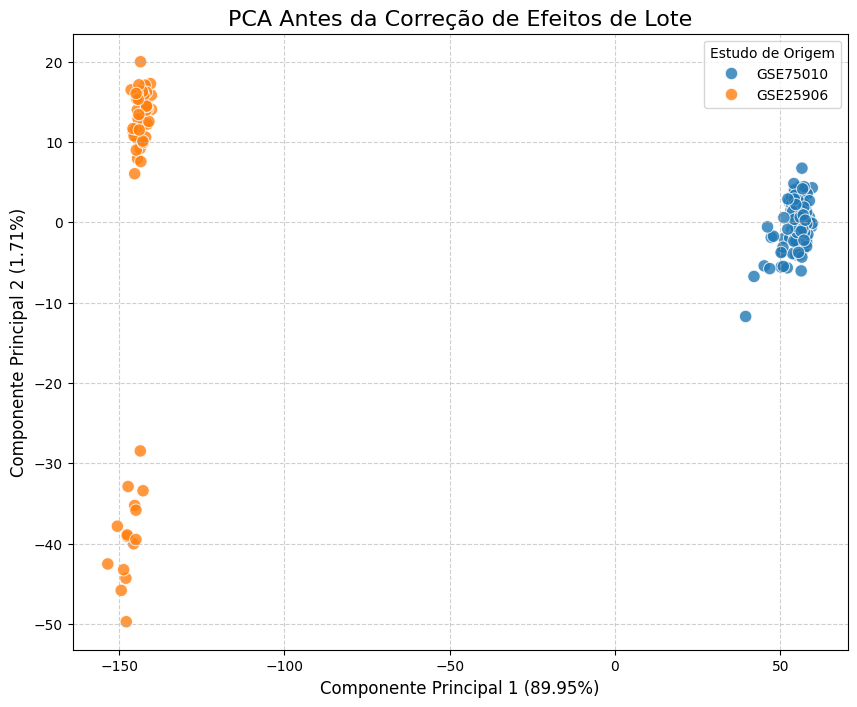


Aplicando ComBat para corrigir os efeitos de lote...
Found 2 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data
✅ Correção com ComBat concluída.

Gerando PCA para validar a correção...


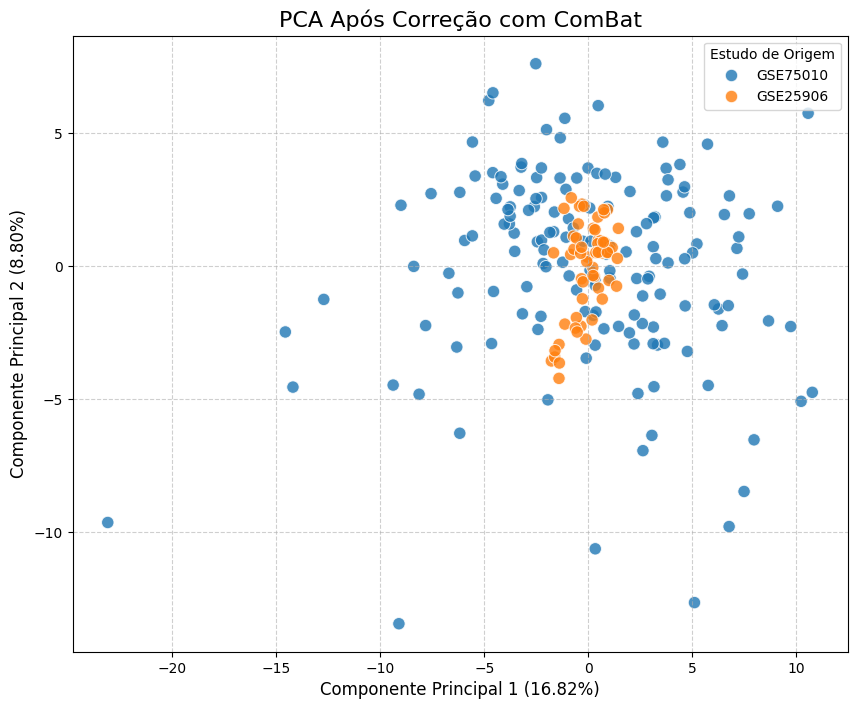

In [ ]:
# ==============================================================================
# PASSO 0: INSTALAÇÃO DAS DEPENDÊNCIAS
# ==============================================================================
# Execute este comando em uma célula separada no Colab antes de rodar o script.
!pip install GEOparse
# ==============================================================================

import pandas as pd
import numpy as np
import GEOparse
import os
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from combat.pycombat import pycombat

# ==============================================================================
# PASSO 1: FUNÇÕES AUXILIARES (COM A CORREÇÃO)
# ==============================================================================

def robust_harmonize_clinical_data_gse75010(df_raw):
    """
    Processa e harmoniza de forma robusta os metadados clínicos brutos do dataset GSE75010.
    """
    harmonized_data = []
    for _, row in df_raw.iterrows():
        sample_id = row['gsm_id']
        characteristics_list = row.get('characteristics_ch1', [])
        char_dict = {}
        if isinstance(characteristics_list, list):
            for item in characteristics_list:
                parts = str(item).split(':', 1)
                if len(parts) == 2:
                    key = parts[0].strip().lower()
                    value = parts[1].strip()
                    char_dict[key] = value

        sample_data = {'sample_id': sample_id}
        diagnosis = char_dict.get('diagnosis', '').lower()
        sample_data['pe_status'] = 1 if 'pe' in diagnosis else 0
        harmonized_data.append(sample_data)

    return pd.DataFrame(harmonized_data)

def plot_pca_batch_effect(expression_df, batch_series, title):
    """
    Realiza PCA e plota os resultados, colorindo as amostras pelo lote (batch).
    """
    if expression_df.empty or expression_df.shape[0] == 0:
        print(f"❌ Erro ao gerar PCA: O dataframe de expressão está vazio. Título: '{title}'")
        return

    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(expression_df.T)

    pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=expression_df.columns)
    pc_df['Batch'] = batch_series.values

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x='PC1', y='PC2', hue='Batch', data=pc_df, s=80, alpha=0.8
    )
    plt.title(title, fontsize=16)
    plt.xlabel(f"Componente Principal 1 ({pca.explained_variance_ratio_[0]:.2%})", fontsize=12)
    plt.ylabel(f"Componente Principal 2 ({pca.explained_variance_ratio_[1]:.2%})", fontsize=12)
    plt.legend(title='Estudo de Origem')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# --- FUNÇÃO DE MAPEAMENTO DE GENES ATUALIZADA ---
def map_probes_to_genes(gse_object):
    """
    Mapeia os IDs de probe para símbolos de gene. Esta versão foi atualizada
    para lidar com a coluna 'gene_assignment' da plataforma GPL6244.
    """
    platform_name = list(gse_object.gpls.keys())[0]
    gpl = gse_object.gpls[platform_name]

    # CORREÇÃO: Adicionada 'gene_assignment' à lista de nomes possíveis
    gene_symbol_col_name = None
    possible_names = ['Gene Symbol', 'GENE_SYMBOL', 'Symbol', 'gene_assignment']
    for name in possible_names:
        if name in gpl.table.columns:
            gene_symbol_col_name = name
            break

    if not gene_symbol_col_name:
        print(f"Colunas disponíveis na plataforma {platform_name}: {gpl.table.columns.tolist()}")
        raise ValueError(f"Não foi possível encontrar a coluna de símbolos de gene na plataforma {platform_name}")

    annotation_map = gpl.table[['ID', gene_symbol_col_name]].dropna().set_index('ID')

    # CORREÇÃO: Se a coluna for 'gene_assignment', extrai o símbolo do gene
    if gene_symbol_col_name == 'gene_assignment':
        print(f"Plataforma {platform_name} usa 'gene_assignment'. Extraindo símbolos de gene...")
        # A coluna tem o formato "RefSeq // Gene Symbol // Gene Title"
        # Nós pegamos o segundo elemento após dividir por " // "
        annotation_map['GENE_SYMBOL_CLEAN'] = annotation_map[gene_symbol_col_name].str.split('//').str[1].str.strip()
        annotation_map = annotation_map.drop(columns=[gene_symbol_col_name]).rename(columns={'GENE_SYMBOL_CLEAN': 'GENE_SYMBOL'})
    else:
        annotation_map = annotation_map.rename(columns={gene_symbol_col_name: 'GENE_SYMBOL'})

    annotation_map = annotation_map[annotation_map['GENE_SYMBOL'] != '---']

    expression_df = gse_object.pivot_samples('VALUE').rename_axis(None, axis=1)
    mapped_expression = expression_df.join(annotation_map)
    mapped_expression = mapped_expression.dropna(subset=['GENE_SYMBOL'])
    mapped_expression = mapped_expression.groupby('GENE_SYMBOL').mean()

    return mapped_expression


# ==============================================================================
# PASSO 2: CARREGAMENTO, DOWNLOAD E PROCESSAMENTO DOS DADOS
# ==============================================================================

print("Baixando e processando GSE75010...")
gse75010 = GEOparse.get_GEO(geo="GSE75010", destdir="./datasets")
clinical_gse75010_raw = pd.DataFrame([gse.metadata for gsm_name, gse in gse75010.gsms.items()])
clinical_gse75010_raw['gsm_id'] = clinical_gse75010_raw.index
clinical_gse75010 = robust_harmonize_clinical_data_gse75010(clinical_gse75010_raw)
expression_gse75010 = map_probes_to_genes(gse75010)
print(f"✅ GSE75010 processado. Dimensões da expressão: {expression_gse75010.shape}")

print("\nBaixando e processando GSE25906...")
gse25906 = GEOparse.get_GEO(geo="GSE25906", destdir="./datasets")
clinical_gse25906_list = []
for gsm_name, gsm in gse25906.gsms.items():
    title = gsm.metadata.get('title', [''])[0].lower()
    status = 1 if 'preeclampsia' in title else 0
    clinical_gse25906_list.append({'sample_id': gsm_name, 'pe_status': status})
clinical_gse25906 = pd.DataFrame(clinical_gse25906_list)
expression_gse25906 = map_probes_to_genes(gse25906)
print(f"✅ GSE25906 processado. Dimensões da expressão: {expression_gse25906.shape}")

# ==============================================================================
# PASSO 3: FUSÃO DOS DADOS E PREPARAÇÃO PARA CORREÇÃO
# ==============================================================================
print("\nFundindo datasets e preparando para correção de lote...")

common_genes = expression_gse75010.index.intersection(expression_gse25906.index)
print(f"Encontrados {len(common_genes)} genes em comum.")

merged_expression = pd.concat([
    expression_gse75010.loc[common_genes],
    expression_gse25906.loc[common_genes]
], axis=1)

batch_info = pd.Series(
    ['GSE75010'] * expression_gse75010.shape[1] + ['GSE25906'] * expression_gse25906.shape[1],
    index=merged_expression.columns,
    name='batch'
)
print("✅ Dados fundidos e vetor de lote criado.")

# ==============================================================================
# PASSO 4: VISUALIZAR, CORRIGIR E VALIDAR
# ==============================================================================

print("\nGerando PCA para visualizar o efeito de lote...")
plot_pca_batch_effect(merged_expression, batch_info, 'PCA Antes da Correção de Efeitos de Lote')

print("\nAplicando ComBat para corrigir os efeitos de lote...")
corrected_expression_df = pycombat(merged_expression, batch_info)
print("✅ Correção com ComBat concluída.")

print("\nGerando PCA para validar a correção...")
plot_pca_batch_effect(corrected_expression_df, batch_info, 'PCA Após Correção com ComBat')

In [ ]:
# ==============================================================================
# PASSO 0: INSTALAÇÃO DA DEPENDÊNCIA
# ==============================================================================
# Garante que a biblioteca gseapy está instalada neste ambiente.
!pip install gseapy -q

# ==============================================================================
# PASSO 1: IMPORTS E DEFINIÇÃO DA FUNÇÃO
# ==============================================================================
import gseapy as gp
import pandas as pd
import os

# A variável 'corrected_expression_df' já deve existir no seu ambiente do Colab
# a partir da execução da célula anterior.

def run_gsva_feature_engineering(expression_df, gmt_file_path):
    """
    Executa ssGSEA (similar a GSVA) para transformar dados de expressão génica
    em pontuações de enriquecimento de vias biológicas.

    Args:
        expression_df (pd.DataFrame): Matriz de expressão corrigida por lote (genes x amostras).
        gmt_file_path (str): Caminho para o ficheiro.gmt com os conjuntos de genes (ex: Hallmark).

    Returns:
        pd.DataFrame: Matriz de pontuações de enriquecimento (vias x amostras),
                      que será transposta posteriormente.
    """
    print("-" * 70)
    print(f"Executando ssGSEA com o ficheiro de conjuntos de genes: {os.path.basename(gmt_file_path)}")

    # O ssGSEA do gseapy é uma implementação eficiente e popular
    ssgsea_results = gp.ssgsea(
        data=expression_df,
        gene_sets=gmt_file_path,
        sample_norm_method='rank', # Método de normalização padrão
        min_size=10,
        max_size=500,
        outdir=None,  # Evita a criação de ficheiros de saída
        verbose=False
    )

    # O resultado vem em um formato longo, então pivotamos para ter vias como linhas
    # e amostras como colunas.
    pathway_scores_df = ssgsea_results.res2d.pivot(index='Term', columns='Name', values='ES')
    print("✅ Engenharia de características com ssGSEA concluída.")
    return pathway_scores_df

# ==============================================================================
# PASSO 2: EXECUÇÃO DA ANÁLISE PARA CADA CONJUNTO DE GENES
# ==============================================================================

# Define os caminhos para os ficheiros .gmt que foram baixados anteriormente.
gmt_paths = {
    'Hallmark': 'datasets/hallmark_gene_sets.gmt',
    'KEGG_MEDICUS': 'datasets/kegg_medicus_gene_sets.gmt',
    'GO_BP': 'datasets/go_bp_gene_sets.gmt'
}

# Dicionário para armazenar os resultados de cada análise
all_pathway_scores = {}

for name, path in gmt_paths.items():
    if os.path.exists(path):
        # Executa a função e armazena o resultado
        scores_df = run_gsva_feature_engineering(corrected_expression_df, path)
        all_pathway_scores[name] = scores_df

        # Mostra um resumo dos resultados para validação
        print(f"\nDimensões da matriz de pontuações '{name}': {scores_df.shape}")
        print("Amostra das primeiras 5 vias e amostras:")
        display(scores_df.iloc[:5, :5])
    else:
        print(f"\n⚠️ Aviso: O ficheiro {path} não foi encontrado. A pular esta análise.")

# ==============================================================================
# PASSO 3: COMBINAÇÃO DAS CARACTERÍSTICAS EM UMA ÚNICA MATRIZ
# ==============================================================================

if all_pathway_scores:
    # Concatena todas as matrizes de pontuação.
    # Como as colunas (amostras) são as mesmas, concatenamos pelas linhas (vias).
    final_features_df = pd.concat(all_pathway_scores.values(), axis=0)

    # A prática comum em Machine Learning é ter amostras nas linhas e características nas colunas.
    # Portanto, transpomos a matriz final.
    final_features_df = final_features_df.T

    print("\n" + "=" * 70)
    print("✨ TODAS AS CARACTERÍSTICAS DE VIAS FORAM COMBINADAS! ✨")
    print("=" * 70)
    print("Esta é a matriz final de características, pronta para ser usada em modelos de Machine Learning.")
    print(f"Dimensões finais (amostras x vias): {final_features_df.shape}")
    print("\nAmostra da matriz de características final:")
    display(final_features_df.head())
else:
    print("\n❌ Nenhuma análise de ssGSEA foi executada. A matriz final não pôde ser criada.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 601.3/601.3 kB 10.8 MB/s eta 0:00:00
----------------------------------------------------------------------
Executando ssGSEA com o ficheiro de conjuntos de genes: hallmark_gene_sets.gmt
✅ Engenharia de características com ssGSEA concluída.

Dimensões da matriz de pontuações 'Hallmark': (50, 217)
Amostra das primeiras 5 vias e amostras:


Name,GSM1940492,GSM1940493,GSM1940494,GSM1940495,GSM1940496
Term,,,,,
HALLMARK_ADIPOGENESIS,3752.048625,3795.94783,3810.18391,3808.540577,3773.769427
HALLMARK_ALLOGRAFT_REJECTION,594.836965,538.457232,632.210348,612.511664,594.76202
HALLMARK_ANDROGEN_RESPONSE,3786.176844,3652.850635,3740.739824,3782.247743,3762.691601
HALLMARK_ANGIOGENESIS,3998.704976,3937.216193,4055.700983,4032.438487,3983.861014
HALLMARK_APICAL_JUNCTION,2652.863596,2619.093577,2693.175248,2590.162507,2605.389116


----------------------------------------------------------------------
Executando ssGSEA com o ficheiro de conjuntos de genes: kegg_medicus_gene_sets.gmt
✅ Engenharia de características com ssGSEA concluída.

Dimensões da matriz de pontuações 'KEGG_MEDICUS': (367, 217)
Amostra das primeiras 5 vias e amostras:


Name,GSM1940492,GSM1940493,GSM1940494,GSM1940495,GSM1940496
Term,,,,,
KEGG_MEDICUS_ENV_FACTOR_ARSENIC_TO_ELECTRON_TRANSFER_IN_COMPLEX_IV,4285.69116,4246.583169,4272.610492,4206.047137,4221.582754
KEGG_MEDICUS_ENV_FACTOR_DCE_TO_DNA_ADDUCTS,819.63106,802.772104,794.856684,920.009985,935.486407
KEGG_MEDICUS_ENV_FACTOR_E2_TO_RAS_ERK_SIGNALING_PATHWAY,3003.710841,3061.272155,2994.035949,3030.220244,3012.490419
KEGG_MEDICUS_ENV_FACTOR_IRON_TO_ANTEROGRADE_AXONAL_TRANSPORT,2125.821364,2215.038241,2275.487453,2087.689748,2123.523137
KEGG_MEDICUS_ENV_FACTOR_METALS_TO_NFKB_SIGNALING_PATHWAY,2942.999594,3022.531977,2973.674615,3024.090087,3093.508585


----------------------------------------------------------------------
Executando ssGSEA com o ficheiro de conjuntos de genes: go_bp_gene_sets.gmt
✅ Engenharia de características com ssGSEA concluída.

Dimensões da matriz de pontuações 'GO_BP': (4916, 217)
Amostra das primeiras 5 vias e amostras:


Name,GSM1940492,GSM1940493,GSM1940494,GSM1940495,GSM1940496
Term,,,,,
GOBP_2_OXOGLUTARATE_METABOLIC_PROCESS,2541.91787,2573.543478,2595.099525,2554.821203,2587.844247
GOBP_3_PHOSPHOADENOSINE_5_PHOSPHOSULFATE_METABOLIC_PROCESS,699.04337,703.946987,921.169639,674.242986,646.371238
GOBP_3_UTR_MEDIATED_MRNA_DESTABILIZATION,3575.076491,3542.502027,3502.268822,3392.803232,3596.810434
GOBP_3_UTR_MEDIATED_MRNA_STABILIZATION,1248.906247,1352.295866,1254.053814,1348.875189,1313.534722
GOBP_4_HYDROXYPROLINE_METABOLIC_PROCESS,2879.345292,2471.241063,2602.236809,2800.143644,2799.214157



✨ TODAS AS CARACTERÍSTICAS DE VIAS FORAM COMBINADAS! ✨
Esta é a matriz final de características, pronta para ser usada em modelos de Machine Learning.
Dimensões finais (amostras x vias): (217, 5333)

Amostra da matriz de características final:


Term,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,HALLMARK_COAGULATION,...,GOBP_XENOBIOTIC_CATABOLIC_PROCESS,GOBP_XENOBIOTIC_EXPORT_FROM_CELL,GOBP_XENOBIOTIC_METABOLIC_PROCESS,GOBP_XENOBIOTIC_TRANSMEMBRANE_TRANSPORT,GOBP_XENOBIOTIC_TRANSPORT,GOBP_XENOPHAGY,GOBP_ZINC_ION_IMPORT_ACROSS_PLASMA_MEMBRANE,GOBP_ZINC_ION_IMPORT_INTO_ORGANELLE,GOBP_ZINC_ION_TRANSPORT,GOBP_ZYMOGEN_ACTIVATION
Name,,,,,,,,,,,,,,,,,,,,,
GSM1940492,3752.048625,594.836965,3786.176844,3998.704976,2652.863596,1368.977313,3157.536952,708.110215,3113.587101,2005.600627,...,-2670.407447,-1.936713,-1355.852156,-70.106796,435.111526,2937.153172,1465.279896,2405.805834,2260.804356,2108.382857
GSM1940493,3795.94783,538.457232,3652.850635,3937.216193,2619.093577,1346.235199,3165.066637,740.816157,3088.793145,2006.070987,...,-2746.670514,107.301011,-1381.040887,-152.477841,430.304093,2928.392025,1458.303111,2500.50168,2325.433927,2128.220913
GSM1940494,3810.18391,632.210348,3740.739824,4055.700983,2693.175248,1383.295912,3187.871875,761.82901,3153.378003,2109.809842,...,-2556.961797,107.854435,-1355.670973,55.040694,566.000181,2812.10827,1544.483865,2448.687904,2286.424539,2083.732075
GSM1940495,3808.540577,612.511664,3782.247743,4032.438487,2590.162507,1369.984714,3213.311495,787.436105,3190.76532,2064.140366,...,-2473.974873,14.036914,-1333.04018,140.227831,519.918162,2886.101736,1542.200806,2478.286541,2281.545933,2127.933065
GSM1940496,3773.769427,594.76202,3762.691601,3983.861014,2605.389116,1383.450622,3194.878152,708.196659,3084.498719,1989.75944,...,-2437.868208,-15.248168,-1373.499281,6.040784,472.687715,2925.619523,1533.659324,2389.214403,2259.41759,2143.722966


In [ ]:
# ==============================================================================
# PASSO 0: IMPORTS E VERIFICAÇÃO DE VARIÁVEIS
# ==============================================================================
# Importa a classe necessária para normalização
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# Verifica se as variáveis das células anteriores existem.
# Se estiver a executar este notebook em uma nova sessão, precisa rodar as células anteriores primeiro.
try:
    final_features_df
    clinical_gse75010
    clinical_gse25906
except NameError:
    print("❌ Erro: Uma ou mais variáveis necessárias ('final_features_df', 'clinical_gse75010', 'clinical_gse25906') não foram encontradas.")
    print("Certifique-se de que executou as células anteriores com sucesso.")
    # Interrompe a execução se as variáveis não existirem
    raise

# ==============================================================================
# PASSO 1: FUSÃO DOS DADOS CLÍNICOS E DAS CARACTERÍSTICAS DE VIAS
# ==============================================================================
print("-" * 70)
print("PASSO 1: Iniciando a fusão dos dados clínicos e das pontuações de vias...")

# Combinar os dataframes clínicos dos dois estudos
# O 'concat' vai alinhar as colunas e preencher com NaN onde não houver correspondência
# (ex: a maioria das colunas clínicas para o estudo GSE25906 serão NaN)
merged_clinical = pd.concat([clinical_gse75010, clinical_gse25906], ignore_index=True)
merged_clinical_indexed = merged_clinical.set_index('sample_id')

# Juntar os dados clínicos com as pontuações das vias (final_features_df)
# O 'join' usa o índice (sample_id) para alinhar as amostras corretamente.
final_matrix = merged_clinical_indexed.join(final_features_df)

# Remover amostras onde a variável alvo ('pe_status') é nula, pois são inúteis para treino
initial_samples = len(final_matrix)
final_matrix.dropna(subset=['pe_status'], inplace=True)
print(f"✅ Dados fundidos. Amostras totais: {initial_samples}. Amostras com rótulo 'pe_status': {len(final_matrix)}.")

# ==============================================================================
# PASSO 2: NORMALIZAÇÃO DE CARACTERÍSTICAS CONTÍNUAS (Z-SCORE)
# ==============================================================================
print("\n" + "-" * 70)
print("PASSO 2: Normalizando características contínuas com StandardScaler...")

# Identificar todas as colunas numéricas que devem ser normalizadas.
# Isso inclui todas as pontuações de vias e as variáveis clínicas contínuas.
pathway_cols = list(final_features_df.columns)
clinical_cols_to_scale = ['gestational_age_weeks', 'systolic_bp', 'diastolic_bp', 'uterine_artery_pi', 'maternal_age', 'maternal_bmi']

# Apenas colunas que realmente existem na nossa matriz final
numeric_cols_to_scale = pathway_cols + [col for col in clinical_cols_to_scale if col in final_matrix.columns]

# Instanciar e aplicar o normalizador
scaler = StandardScaler()
# Usamos .loc para garantir que estamos a modificar o DataFrame original de forma segura
final_matrix.loc[:, numeric_cols_to_scale] = scaler.fit_transform(final_matrix[numeric_cols_to_scale])
print("✅ Normalização concluída.")

# ==============================================================================
# PASSO 3: GESTÃO DE DADOS EM FALTA (IMPUTAÇÃO PELA MÉDIA)
# ==============================================================================
print("\n" + "-" * 70)
print("PASSO 3: Imputando dados em falta preenchendo com a média da coluna...")

# Após a normalização, a média de cada coluna é ~0. Preencher com 0 é equivalente a preencher com a média.
# Esta é uma estratégia simples e eficaz para dados normalizados por Z-score.
missing_before = final_matrix[numeric_cols_to_scale].isnull().sum().sum()
final_matrix[numeric_cols_to_scale] = final_matrix[numeric_cols_to_scale].fillna(0)
missing_after = final_matrix[numeric_cols_to_scale].isnull().sum().sum()

print(f"Valores em falta imputados: {missing_before}. Valores restantes: {missing_after}.")
print("✅ Imputação concluída.")

# ==============================================================================
# PASSO 4: RESULTADO FINAL
# ==============================================================================
print("\n" + "=" * 70)
print("✨ MATRIZ FINAL DE CARACTERÍSTICAS CONSTRUÍDA E PRONTA! ✨")
print("=" * 70)
print("Esta matriz pode ser usada diretamente para treinar modelos de Machine Learning.")
print(f"Dimensões finais (amostras x características): {final_matrix.shape}")
print("\nAmostra da matriz final:")
display(final_matrix.head())


----------------------------------------------------------------------
PASSO 1: Iniciando a fusão dos dados clínicos e das pontuações de vias...
✅ Dados fundidos. Amostras totais: 217. Amostras com rótulo 'pe_status': 217.

----------------------------------------------------------------------
PASSO 2: Normalizando características contínuas com StandardScaler...
✅ Normalização concluída.

----------------------------------------------------------------------
PASSO 3: Imputando dados em falta preenchendo com a média da coluna...


/tmp/ipython-input-296686047.py:71: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_matrix[numeric_cols_to_scale] = final_matrix[numeric_cols_to_scale].fillna(0)


Valores em falta imputados: 837281. Valores restantes: 0.
✅ Imputação concluída.

✨ MATRIZ FINAL DE CARACTERÍSTICAS CONSTRUÍDA E PRONTA! ✨
Esta matriz pode ser usada diretamente para treinar modelos de Machine Learning.
Dimensões finais (amostras x características): (217, 5334)

Amostra da matriz final:


,pe_status,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,GOBP_XENOBIOTIC_CATABOLIC_PROCESS,GOBP_XENOBIOTIC_EXPORT_FROM_CELL,GOBP_XENOBIOTIC_METABOLIC_PROCESS,GOBP_XENOBIOTIC_TRANSMEMBRANE_TRANSPORT,GOBP_XENOBIOTIC_TRANSPORT,GOBP_XENOPHAGY,GOBP_ZINC_ION_IMPORT_ACROSS_PLASMA_MEMBRANE,GOBP_ZINC_ION_IMPORT_INTO_ORGANELLE,GOBP_ZINC_ION_TRANSPORT,GOBP_ZYMOGEN_ACTIVATION
sample_id,,,,,,,,,,,,,,,,,,,,,
0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd
import numpy as np

# ==============================================================================
# PASSO 1: SCRIPT DE ANÁLISE DE COLUNAS
# ==============================================================================
# Assume-se que a variável 'final_matrix' já existe no ambiente do Colab.

print("Iniciando a análise detalhada de cada coluna da matriz final...")

# Lista para armazenar os resultados da análise de cada coluna
analysis_results = []

# Iterar por cada coluna da matriz de características
for column in final_matrix.columns:
    col_data = final_matrix[column]

    # Calcular as métricas solicitadas
    mean_val = col_data.mean()
    zero_count = (col_data == 0).sum()
    total_count = len(col_data)
    zero_percentage = (zero_count / total_count) * 100
    is_all_zeros = zero_count == total_count
    is_all_nan = col_data.isnull().all()

    # Armazenar os resultados em um dicionário
    analysis_results.append({
        'Coluna': column,
        'Média': mean_val,
        'Contagem de Zeros': zero_count,
        'Percentual de Zeros (%)': zero_percentage,
        'Todos os Valores São Zero': is_all_zeros,
        'Todos os Valores São NaN': is_all_nan
    })

# Converter a lista de resultados em um DataFrame do Pandas
analysis_df = pd.DataFrame(analysis_results)

# ==============================================================================
# PASSO 2: EXIBIÇÃO DOS RESULTADOS E SUMÁRIOS
# ==============================================================================

print("\n" + "=" * 70)
print("✨ RESUMO DA ANÁLISE DAS COLUNAS ✨")
print("=" * 70)

cols_all_zeros = analysis_df[analysis_df['Todos os Valores São Zero']].shape[0]
print(f"Total de colunas analisadas: {len(final_matrix.columns)}")
print(f"Número de colunas onde TODOS os valores são zero: {cols_all_zeros}")

# Identificar colunas que são majoritariamente zeros (ex: >40%), que provavelmente
# correspondem aos dados clínicos que estavam faltando em um dos estudos.
# O estudo GSE25906 tem 60 amostras de um total de 217 (~27%). O outro estudo tem 157 amostras.
# Variáveis que só existem no GSE75010 terão 60/217 = ~27.6% de valores imputados (zeros).
# Variáveis que só existem no GSE25906 teriam 157/217 = ~72% de valores imputados.
high_zero_cols = analysis_df[analysis_df['Percentual de Zeros (%)'] > 25]
print(f"Número de colunas com mais de 25% de valores zero: {len(high_zero_cols)}")

if not high_zero_cols.empty:
    print("\nAmostra de colunas com alta porcentagem de zeros (provavelmente dados clínicos imputados):")
    # Mostrando as colunas com a maior % de zeros
    display(high_zero_cols.sort_values(by='Percentual de Zeros (%)', ascending=False).head(10))

print("\n" + "=" * 70)
print("TABELA DE ANÁLISE COMPLETA (PRIMEIRAS 100 LINHAS)")
print("=" * 70)
# Configuração para exibir mais linhas do DataFrame de análise
pd.set_option('display.max_rows', 100)
display(analysis_df.head(100))


Iniciando a análise detalhada de cada coluna da matriz final...

✨ RESUMO DA ANÁLISE DAS COLUNAS ✨
Total de colunas analisadas: 5334
Número de colunas onde TODOS os valores são zero: 0
Número de colunas com mais de 25% de valores zero: 5334

Amostra de colunas com alta porcentagem de zeros (provavelmente dados clínicos imputados):


,Coluna,Média,Contagem de Zeros,Percentual de Zeros (%),Todos os Valores São Zero,Todos os Valores São NaN
5333,GOBP_ZYMOGEN_ACTIVATION,2.268539e-15,157,72.35023,False,False
5332,GOBP_ZINC_ION_TRANSPORT,2.227097e-15,157,72.35023,False,False
1,HALLMARK_ADIPOGENESIS,3.209542e-15,157,72.35023,False,False
2,HALLMARK_ALLOGRAFT_REJECTION,-6.459247e-16,157,72.35023,False,False
3,HALLMARK_ANDROGEN_RESPONSE,4.026477e-16,157,72.35023,False,False
5316,GOBP_WATER_SOLUBLE_VITAMIN_BIOSYNTHETIC_PROCESS,-1.023247e-16,157,72.35023,False,False
5315,GOBP_WALKING_BEHAVIOR,5.116235e-18,157,72.35023,False,False
5314,GOBP_V_D_J_RECOMBINATION,2.015797e-16,157,72.35023,False,False
5313,GOBP_VOCALIZATION_BEHAVIOR,-2.680907e-16,157,72.35023,False,False
5312,GOBP_VITAMIN_TRANSPORT,-1.116363e-15,157,72.35023,False,False



TABELA DE ANÁLISE COMPLETA (PRIMEIRAS 100 LINHAS)


,Coluna,Média,Contagem de Zeros,Percentual de Zeros (%),Todos os Valores São Zero,Todos os Valores São NaN
0,pe_status,7.235023e-01,60,27.64977,False,False
1,HALLMARK_ADIPOGENESIS,3.209542e-15,157,72.35023,False,False
2,HALLMARK_ALLOGRAFT_REJECTION,-6.459247e-16,157,72.35023,False,False
3,HALLMARK_ANDROGEN_RESPONSE,4.026477e-16,157,72.35023,False,False
4,HALLMARK_ANGIOGENESIS,1.921462e-15,157,72.35023,False,False
5,HALLMARK_APICAL_JUNCTION,3.705177e-15,157,72.35023,False,False
6,HALLMARK_APICAL_SURFACE,2.059477e-15,157,72.35023,False,False
7,HALLMARK_APOPTOSIS,-8.552235e-15,157,72.35023,False,False
8,HALLMARK_BILE_ACID_METABOLISM,-2.811371e-15,157,72.35023,False,False
9,HALLMARK_CHOLESTEROL_HOMEOSTASIS,6.383015e-15,157,72.35023,False,False
